In [1]:
import pytensor
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import xarray as xr
import sys
import matplotlib.pyplot as plt
import multiprocessing
import statsmodels.api as sm

In [2]:
np.random.seed(1)

#### Bayesian Logistic Regression and Interpret the Posterior

In [3]:
# Simulating binary data.

n = 200

x = np.random.normal(0, 1, n)

true_intercept = -0.5
true_slope = 2.0

logits = true_intercept + true_slope * x

probability = 1 / (1 + np.exp(-logits))

y = np.random.binomial(
    n=1,
    p=probability,
    size=n
)

print("Number of observations: ", n)
print("Number of successes: ", np.sum(y))

Number of observations:  200
Number of successes:  84


In [4]:
# Building the Bayesian logistic regression model.

with pm.Model() as logistic_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    logits = intercept + slope * x

    p = pm.math.sigmoid(logits)

    outcome = pm.Bernoulli(
        "outcome",
        p=p,
        observed=y
    )

    logistic_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 49 seconds.


Posterior Summary:
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.801  0.206    -1.210     -0.401      0.003    0.002    5847.0   
slope      2.290  0.337     1.663      2.972      0.005    0.004    5362.0   

           ess_tail  r_hat  
intercept    5367.0    1.0  
slope        4658.0    1.0  

Posterior Means:
Intercept: -0.801
Slope: 2.29


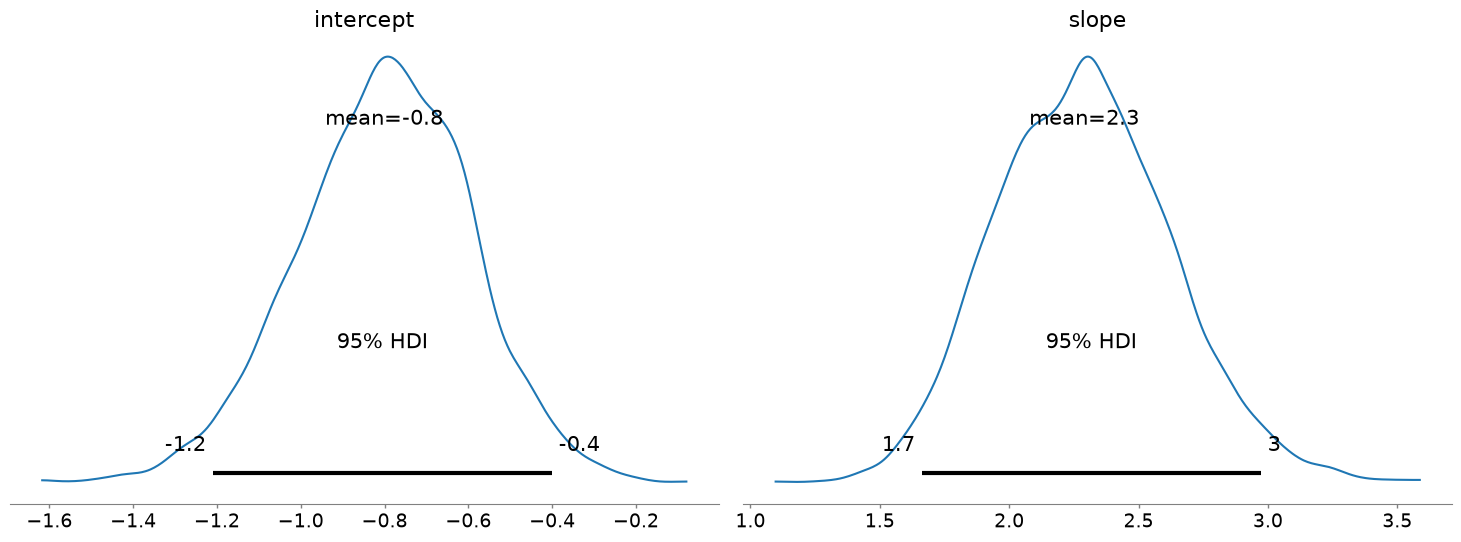

In [60]:
# Posterior summary.

summary = az.summary(
    logistic_trace,
    hdi_prob=0.95
)


print("Posterior Summary:\n", summary)

print("\nPosterior Means:")

print("Intercept:", round(summary.loc["intercept", "mean"], 3))

print("Slope:", round(summary.loc["slope", "mean"], 3))

# Posterior distributions.

az.plot_posterior(
    logistic_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

plt.tight_layout()

plt.show()

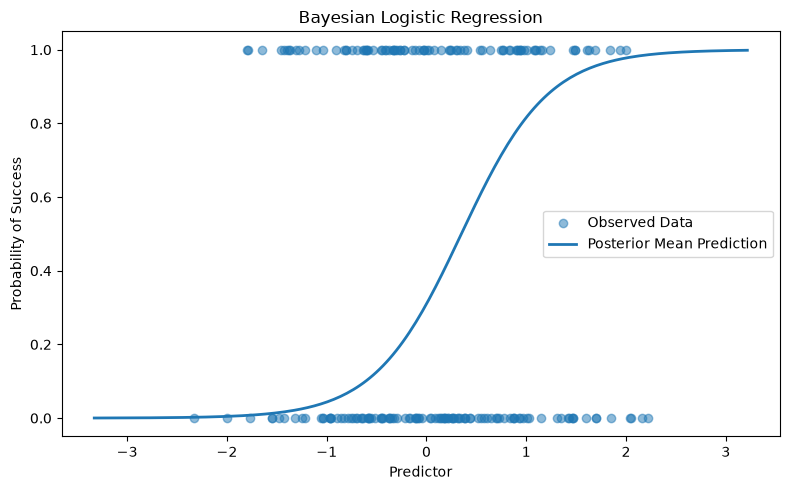

In [61]:
# Decision boundary

posterior_intercept = (
    logistic_trace.posterior["intercept"]
    .mean(dim=("chain", "draw"))
    .values
)

posterior_slope = (
    logistic_trace.posterior["slope"]
    .mean(dim=("chain", "draw"))
    .values
)

x_grid = np.linspace(
    x.min() - 1,
    x.max() + 1,
    200
)

predicted_probability = 1 / (1 + np.exp( - (posterior_intercept + posterior_slope * x_grid)))

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_grid,
    predicted_probability,
    linewidth=2,
    label="Posterior Mean Prediction"
)

plt.title("Bayesian Logistic Regression")
plt.xlabel("Predictor")
plt.ylabel("Probability of Success")

plt.legend()

plt.tight_layout()

plt.show()

#### Bayesian Poisson Regression and Count Data

In [62]:
# Simulating count data.

n = 200

x = np.random.uniform(0, 5, n)

true_intercept = 1.0
true_slope = 0.4

log_rate = true_intercept + true_slope * x

rate = np.exp(log_rate)

counts = np.random.poisson(
    lam=rate,
    size=n
)

print("Number of observations: ", n)
print("Average count: ", round(counts.mean(), 2))

Number of observations:  200
Average count:  7.93


In [8]:
# Building the Bayesian Poisson regression model.

with pm.Model() as poisson_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    log_lambda = intercept + slope * x

    lambda_ = pm.math.exp(log_lambda)

    outcome = pm.Poisson(
        "outcome",
        mu=lambda_,
        observed=counts
    )

    poisson_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 44 seconds.


Posterior Summary:
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept  1.040  0.062     0.920      1.162      0.001    0.001    2134.0   
slope      0.398  0.018     0.365      0.434      0.000    0.000    2104.0   

           ess_tail  r_hat  
intercept    2223.0    1.0  
slope        2294.0    1.0  

Posterior Means: 
Intercept: 1.04
Slope: 0.398


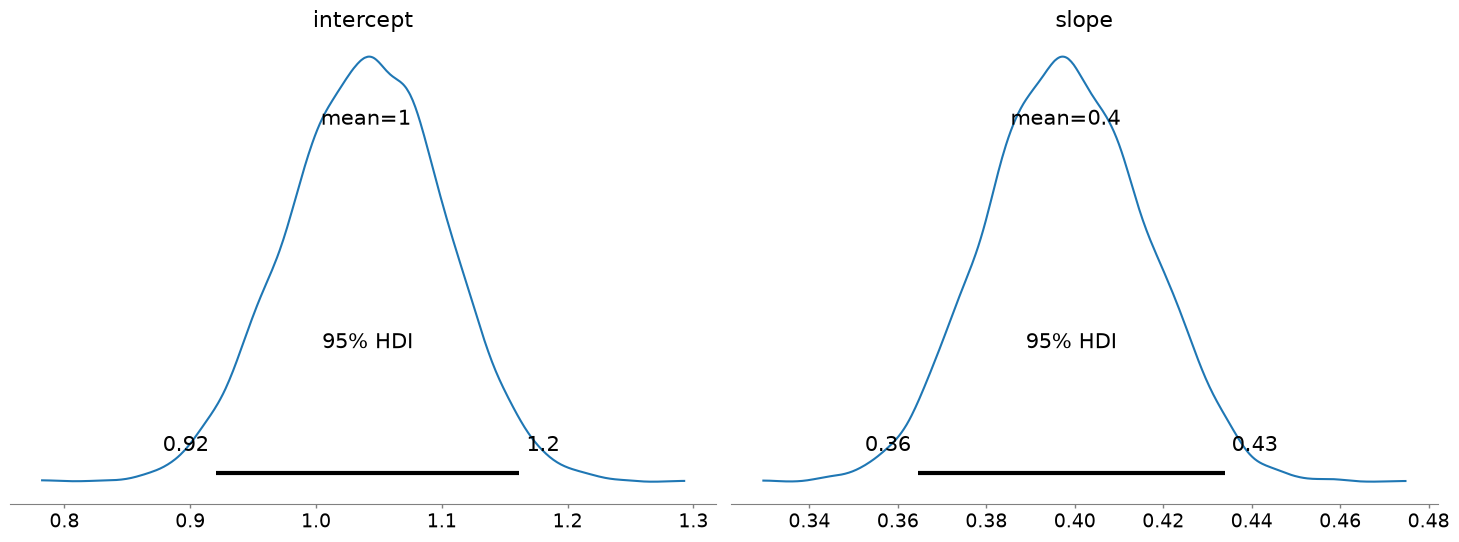

In [63]:
# Posterior summary

summary = az.summary(
    poisson_trace,
    hdi_prob=0.95
)

print("Posterior Summary:\n", summary)

print("\nPosterior Means: ")

print("Intercept:",
      round(summary.loc["intercept", "mean"], 3))

print("Slope:",
      round(summary.loc["slope", "mean"], 3))

# Posterior distributions.

az.plot_posterior(
    poisson_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

plt.tight_layout()

plt.show()

In [64]:
# Frequentist Logistic Regression

X_logistic = sm.add_constant(x)

logistic_model = sm.Logit(y, X_logistic)

logistic_result = logistic_model.fit(disp=False)

print("Frequentist Logistic Regression:\n", logistic_result.summary())

# Bayesian Logistic Regression

bayes_logistic = az.summary(
    logistic_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

print("\nBayesian Logistic Regression:\n", bayes_logistic)

Frequentist Logistic Regression:
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Fri, 03 Jul 2026   Pseudo R-squ.:                0.001861
Time:                        21:11:36   Log-Likelihood:                -137.16
converged:                       True   LL-Null:                       -137.42
Covariance Type:            nonrobust   LLR p-value:                    0.4745
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0505      0.277     -0.182      0.855      -0.594       0.493
x1            -0.0729      0.102     -0.714      0.475      -0.273       0.127

Bayesian Logistic

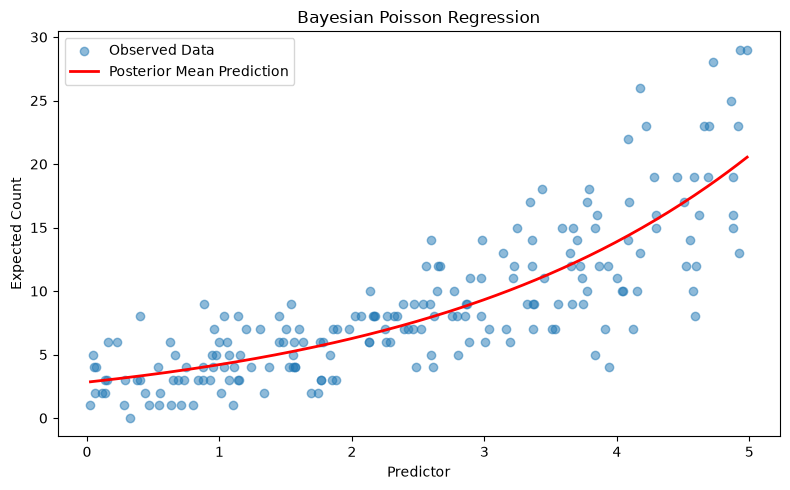

In [10]:
# Visualizing predicted counts.

posterior_intercept = (
    poisson_trace.posterior["intercept"]
    .mean(dim=("chain", "draw"))
    .values
)

posterior_slope = (
    poisson_trace.posterior["slope"]
    .mean(dim=("chain", "draw"))
    .values
)

x_grid = np.linspace(
    x.min(),
    x.max(),
    200
)

predicted_counts = np.exp(
    posterior_intercept +
    posterior_slope * x_grid
)

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    counts,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_grid,
    predicted_counts,
    color="red",
    linewidth=2,
    label="Posterior Mean Prediction"
)

plt.title("Bayesian Poisson Regression")
plt.xlabel("Predictor")
plt.ylabel("Expected Count")

plt.legend()

plt.tight_layout()

plt.show()

#### Compare Bayesian GLMs with Frequentist GLMs

In [12]:
# Frequentist Poisson Regression

X_poisson = sm.add_constant(x)

poisson_model = sm.GLM(
    counts,
    X_poisson,
    family=sm.families.Poisson()
)

poisson_result = poisson_model.fit()

print("Frequentist Poisson Regression:\n", poisson_result.summary())

# Bayesian Poisson Regression

bayes_poisson = az.summary(
    poisson_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

print("Bayesian Poisson Regression:\n", bayes_poisson)

Frequentist Poisson Regression:
                  Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      198
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -489.39
Date:                Fri, 03 Jul 2026   Deviance:                       222.31
Time:                        21:02:02   Pearson chi2:                     214.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9243
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.04

In [13]:
# Comparing interval estimates.

print("95% Frequentist Confidence Intervals (Logistic):\n", logistic_result.conf_int())

print("\n95% Bayesian Credible Intervals (Logistic):\n", bayes_logistic[["mean", "hdi_2.5%", "hdi_97.5%"]])

print("\n95% Frequentist Confidence Intervals (Poisson):\n", poisson_result.conf_int())

print("\n95% Bayesian Credible Intervals (Poisson):\n", bayes_poisson[["mean", "hdi_2.5%", "hdi_97.5%"]])

95% Frequentist Confidence Intervals (Logistic):
 [[-0.92020316  0.19524626]
 [-0.1816265   0.21428382]]

95% Bayesian Credible Intervals (Logistic):
             mean  hdi_2.5%  hdi_97.5%
intercept -0.801    -1.210     -0.401
slope      2.290     1.663      2.972

95% Frequentist Confidence Intervals (Poisson):
 [[0.91799551 1.16452311]
 [0.36186696 0.43321348]]

95% Bayesian Credible Intervals (Poisson):
             mean  hdi_2.5%  hdi_97.5%
intercept  1.040     0.920      1.162
slope      0.398     0.365      0.434


#### Compare Different Priors in Bayesian Logistic Regression

In [14]:
# Simulating binary data.

n = 200

x = np.random.normal(0, 1, n)

true_intercept = -0.5
true_slope = 2.0

logits = true_intercept + true_slope * x

probability = 1 / (1 + np.exp(-logits))

y = np.random.binomial(
    n=1,
    p=probability,
    size=n
)

print("Number of observations: ", n)

Number of observations:  200


In [15]:
# Model 1: Flat prior (very weak Normal).

with pm.Model() as flat_prior_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=100
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=100
    )

    p = pm.math.sigmoid(intercept + slope * x)

    pm.Bernoulli(
        "y",
        p=p,
        observed=y
    )

    flat_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 48 seconds.


In [16]:
# Model 2: Normal(0,1) prior.

with pm.Model() as normal_prior_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=1
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=1
    )

    p = pm.math.sigmoid(intercept + slope * x)

    pm.Bernoulli(
        "y",
        p=p,
        observed=y
    )

    normal_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 58 seconds.


In [17]:
# Model 3: Cauchy prior.

with pm.Model() as cauchy_prior_model:

    intercept = pm.Cauchy(
        "intercept",
        alpha=0,
        beta=2.5
    )

    slope = pm.Cauchy(
        "slope",
        alpha=0,
        beta=2.5
    )

    p = pm.math.sigmoid(intercept + slope * x)

    pm.Bernoulli(
        "y",
        p=p,
        observed=y
    )

    cauchy_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 51 seconds.


In [18]:
# Posterior summaries

print("Flat Prior:\n", az.summary(flat_trace, var_names=["intercept", "slope"]))

print("\nNormal(0,1) Prior:\n", az.summary(normal_trace, var_names=["intercept", "slope"]))

print("\nCauchy(0,2.5) Prior:\n", az.summary(cauchy_trace, var_names=["intercept", "slope"]))

Flat Prior:
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.902  0.256  -1.377   -0.425      0.004    0.003    4684.0   
slope      3.401  0.500   2.497    4.360      0.007    0.005    4867.0   

           ess_tail  r_hat  
intercept    4414.0    1.0  
slope        4888.0    1.0  

Normal(0,1) Prior:
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.721  0.218  -1.132   -0.318      0.003    0.003    6518.0   
slope      2.800  0.373   2.132    3.520      0.005    0.004    5890.0   

           ess_tail  r_hat  
intercept    5295.0    1.0  
slope        5423.0    1.0  

Cauchy(0,2.5) Prior:
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.862  0.252  -1.324   -0.376      0.004    0.003    5112.0   
slope      3.296  0.489   2.375    4.188      0.007    0.006    4900.0   

           ess_tail  r_hat  
intercept    4923.0    1.0  
slope        4466.0    1.0  


#### Prior Predictive Simulation

In [19]:
# Creating predictor values.

n = 200

x = np.random.normal(0, 1, n)

In [20]:
# Building the model.

with pm.Model() as prior_predictive_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=1
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=1
    )

    p = pm.math.sigmoid(
        intercept + slope * x
    )

    outcome = pm.Bernoulli(
        "outcome",
        p=p
    )

    prior = pm.sample_prior_predictive(
        samples=500,
        random_seed=42
    )

Sampling: [intercept, outcome, slope]


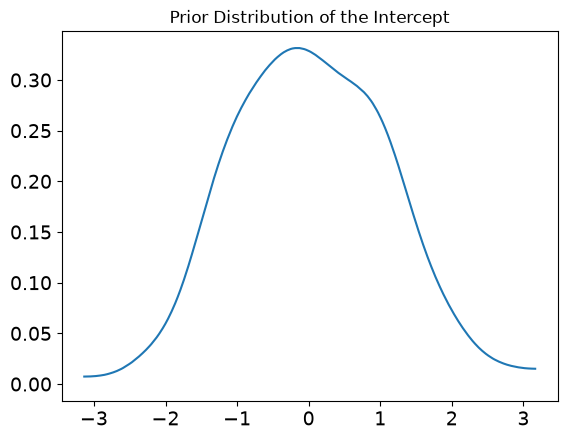

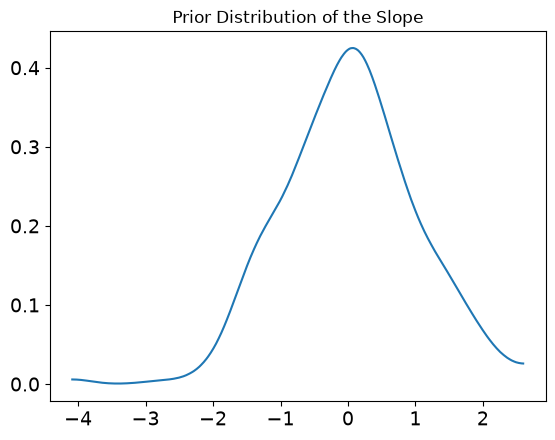

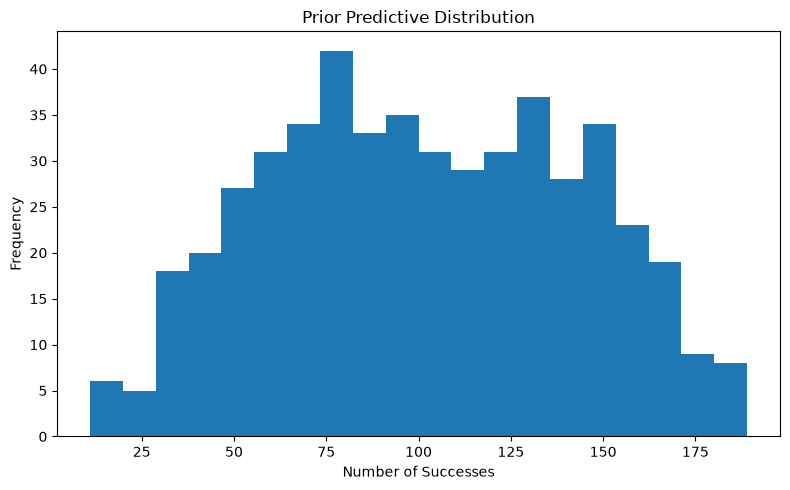

Average predicted successes:  101.46
Minimum predicted successes:  11
Maximum predicted successes:  189


In [43]:
# Visualizing prior distributions.

az.plot_dist(prior.prior["intercept"])

plt.title("Prior Distribution of the Intercept")

plt.show()

az.plot_dist(prior.prior["slope"])

plt.title("Prior Distribution of the Slope")

plt.show()

# Visualizing prior predictive outcomes.

predicted_successes = (
    prior.prior["outcome"]
    .sum(dim="outcome_dim_0")
    .values
)

predicted_successes = predicted_successes.ravel()

plt.figure(figsize=(8, 5))

plt.hist(
    predicted_successes,
    bins=20
)

plt.title("Prior Predictive Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

# Summary

print("Average predicted successes: ",round(predicted_successes.mean(), 2))

print("Minimum predicted successes: ", predicted_successes.min())

print("Maximum predicted successes: ", predicted_successes.max())

#### Effect of Different Priors

In [44]:
# Posterior summaries.

flat_summary = az.summary(
    flat_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

normal_summary = az.summary(
    normal_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

cauchy_summary = az.summary(
    cauchy_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

print("Flat Prior:\n", flat_summary)

print("\nNormal(0,1) Prior:\n", normal_summary)

print("\nCauchy(0,2.5) Prior:\n", cauchy_summary)


Flat Prior:
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.902  0.256    -1.396     -0.402      0.004    0.003    4684.0   
slope      3.401  0.500     2.465      4.421      0.007    0.005    4867.0   

           ess_tail  r_hat  
intercept    4414.0    1.0  
slope        4888.0    1.0  

Normal(0,1) Prior:
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.721  0.218    -1.132     -0.279      0.003    0.003    6518.0   
slope      2.800  0.373     2.111      3.554      0.005    0.004    5890.0   

           ess_tail  r_hat  
intercept    5295.0    1.0  
slope        5423.0    1.0  

Cauchy(0,2.5) Prior:
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.862  0.252    -1.343     -0.361      0.004    0.003    5112.0   
slope      3.296  0.489     2.395      4.284      0.007    0.006    4900.0   

           ess_tail  r_hat  
intercept    4923.0    1.0  
slope 

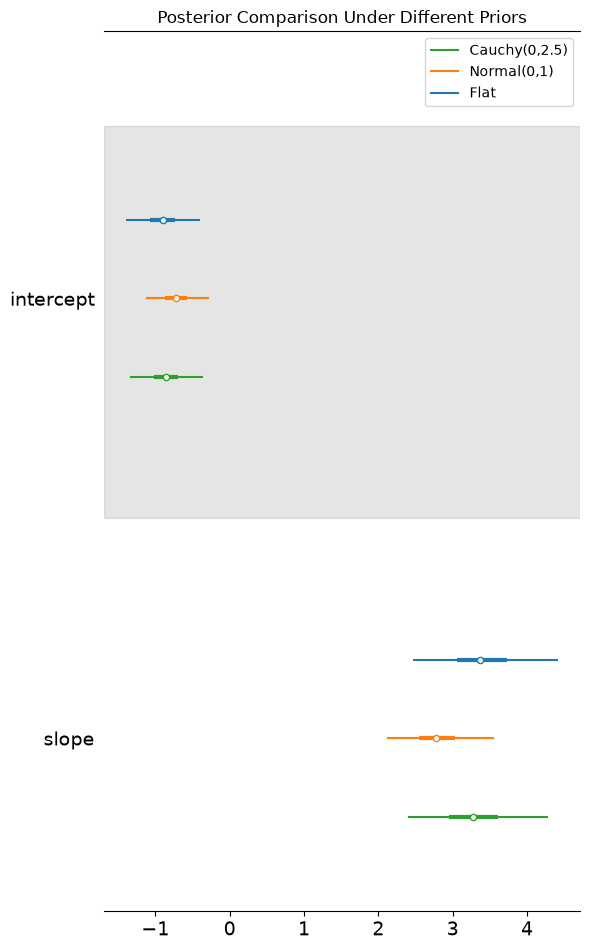

In [45]:
# Posterior comparison plots.

az.plot_forest(
    [flat_trace, normal_trace, cauchy_trace],
    model_names=[
        "Flat",
        "Normal(0,1)",
        "Cauchy(0,2.5)"
    ],
    var_names=["intercept", "slope"],
    combined=True,
    hdi_prob=0.95
)

plt.title("Posterior Comparison Under Different Priors")

plt.tight_layout()

plt.show()

In [46]:
# Posterior means.

print("Flat Prior:", flat_summary["mean"].round(3).to_dict())

print("Normal(0,1) Prior:", normal_summary["mean"].round(3).to_dict())

print("Cauchy(0,2.5) Prior:", cauchy_summary["mean"].round(3).to_dict())

Flat Prior: {'intercept': -0.902, 'slope': 3.401}
Normal(0,1) Prior: {'intercept': -0.721, 'slope': 2.8}
Cauchy(0,2.5) Prior: {'intercept': -0.862, 'slope': 3.296}


#### Posterior Summary Statistics and Credible Intervals

In [47]:
# Computing posterior summary statistics.

summary = az.summary(
    logistic_trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

print("Posterior Summary:\n", summary)

Posterior Summary:
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.801  0.206    -1.210     -0.401      0.003    0.002    5847.0   
slope      2.290  0.337     1.663      2.972      0.005    0.004    5362.0   

           ess_tail  r_hat  
intercept    5367.0    1.0  
slope        4658.0    1.0  


In [48]:
# Posterior means.

intercept_mean = summary.loc["intercept", "mean"]
slope_mean = summary.loc["slope", "mean"]

print("Intercept:", round(intercept_mean, 3))
print("Slope:", round(slope_mean, 3))

Intercept: -0.801
Slope: 2.29


In [49]:
# Posterior medians.

intercept_samples = (
    logistic_trace.posterior["intercept"]
    .values
    .flatten()
)

slope_samples = (
    logistic_trace.posterior["slope"]
    .values
    .flatten()
)

intercept_median = np.median(intercept_samples)
slope_median = np.median(slope_samples)

print("Intercept:", round(intercept_median, 3))
print("Slope:", round(slope_median, 3))

Intercept: -0.794
Slope: 2.285


In [50]:
# 95% Credible intervals.

print(
    "Intercept: [",
    round(summary.loc["intercept", "hdi_2.5%"], 3),
    ",",
    round(summary.loc["intercept", "hdi_97.5%"], 3),
    "]"
)

print(
    "Slope: [",
    round(summary.loc["slope", "hdi_2.5%"], 3),
    ",",
    round(summary.loc["slope", "hdi_97.5%"], 3),
    "]"
)

Intercept: [ -1.21 , -0.401 ]
Slope: [ 1.663 , 2.972 ]


In [51]:
# Posterior standard deviations.

print(
    "Intercept:",
    round(summary.loc["intercept", "sd"], 3)
)

print(
    "Slope:",
    round(summary.loc["slope", "sd"], 3)
)

Intercept: 0.206
Slope: 0.337


#### Effect Threshold

In [52]:
# Extracting posterior samples.

slope_samples = (
    logistic_trace.posterior["slope"]
    .values
    .flatten()
)

In [53]:
# Computing posterior probabilities.

prob_positive = np.mean(slope_samples > 0)

prob_above_threshold = np.mean(slope_samples > 0.2)

print("P(slope > 0): ", round(prob_positive, 4))

print("P(slope > 0.2): ", round(prob_above_threshold, 4))

P(slope > 0):  1.0
P(slope > 0.2):  1.0


In [54]:
# Computing additional probabilities.

prob_negative = np.mean(slope_samples < 0)

prob_between = np.mean((slope_samples > 1.5) & (slope_samples < 2.5))

print("P(slope < 0):", round(prob_negative, 4))

print("P(1.5 < slope < 2.5):", round(prob_between, 4))

P(slope < 0): 0.0
P(1.5 < slope < 2.5): 0.7338


#### Posterior Results

In [55]:
# Extracting posterior samples.

intercept_samples = (
    logistic_trace.posterior["intercept"]
    .values
    .flatten()
)

slope_samples = (
    logistic_trace.posterior["slope"]
    .values
    .flatten()
)

In [56]:
# Computing posterior summaries.

intercept_mean = np.mean(intercept_samples)
slope_mean = np.mean(slope_samples)

intercept_ci = np.percentile(
    intercept_samples,
    [2.5, 97.5]
)

slope_ci = np.percentile(
    slope_samples,
    [2.5, 97.5]
)

prob_positive = np.mean(slope_samples > 0)

In [57]:
# Reporting the results.

print("Intercept:")

print("Posterior mean: ", round(intercept_mean, 3))

print("95% Credible Interval: ",
      f"[{intercept_ci[0]:.3f}, {intercept_ci[1]:.3f}]")

print("\nSlope:")

print("Posterior mean: ", round(slope_mean, 3))

print("95% Credible Interval: ",
      f"[{slope_ci[0]:.3f}, {slope_ci[1]:.3f}]")

print("P(slope > 0):", round(prob_positive, 4))

print("\nInterpretation:")

if prob_positive > 0.95:
    print("There is strong Bayesian evidence that the predictor has a positive effect on the outcome.")
elif prob_positive > 0.80:
    print("There is moderate Bayesian evidence that the predictor has a positive effect on the outcome.")
else:
    print("The evidence for a positive effect is weak or uncertain.")

print("\nThe posterior mean estimates the most plausible value of the effect after combining the prior information with the observed data.")
print("The 95% credible interval represents the range that contains the parameter with 95% posterior probability.")
print("The posterior probability directly quantifies the probability that the effect is positive.")

Intercept:
Posterior mean:  -0.801
95% Credible Interval:  [-1.223, -0.411]

Slope:
Posterior mean:  2.29
95% Credible Interval:  [1.670, 2.985]
P(slope > 0): 1.0

Interpretation:
There is strong Bayesian evidence that the predictor has a positive effect on the outcome.

The posterior mean estimates the most plausible value of the effect after combining the prior information with the observed data.
The 95% credible interval represents the range that contains the parameter with 95% posterior probability.
The posterior probability directly quantifies the probability that the effect is positive.


#### Generate Posterior Predictive Datasets

In [67]:
# Rebuilding the Bayesian logistic regression model.

with pm.Model() as bayesian_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    p = pm.math.sigmoid(
        intercept + slope * x
    )

    outcome = pm.Bernoulli(
        "outcome",
        p=p,
        observed=y
    )

# Generating posterior predictive samples.

with bayesian_model:

    posterior_predictive = pm.sample_posterior_predictive(
        logistic_trace,
        random_seed=42
    )

# Displaying the generated data.


print("InferenceData Groups:\n", posterior_predictive.groups())

print("\nPosterior Predictive Variables:\n", posterior_predictive.posterior_predictive.data_vars)

print("\nPosterior Predictive Shape:\n", posterior_predictive.posterior_predictive["outcome"].shape)

Sampling: [outcome]


Output()

InferenceData Groups:
 ['posterior_predictive', 'observed_data']

Posterior Predictive Variables:
 Data variables:
    outcome  (chain, draw, outcome_dim_0) int64 13MB 1 1 1 1 1 1 ... 1 1 1 1 1 1

Posterior Predictive Shape:
 (4, 2000, 200)


#### Posterior Predictive Check

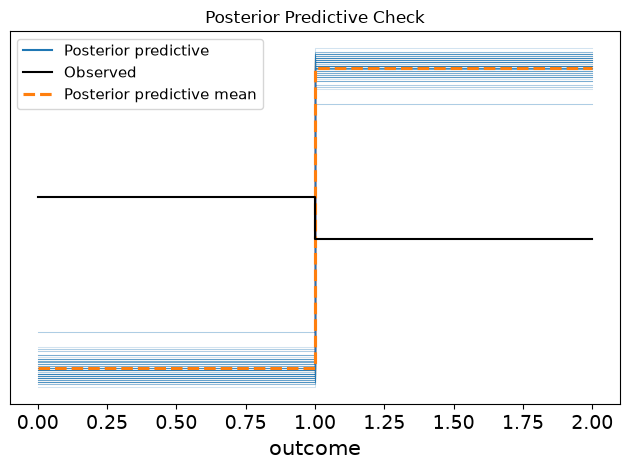

In [69]:
# Posterior Predictive Check (Observed vs Simulated).

az.plot_ppc(
    posterior_predictive,
    data_pairs={"outcome": "outcome"},
    num_pp_samples=100
)

plt.title("Posterior Predictive Check")

plt.tight_layout()

plt.show()

In [71]:
# Comparing summary statistics.

observed = posterior_predictive.observed_data["outcome"].values

predicted = (
    posterior_predictive.posterior_predictive["outcome"]
    .values
)

# Flatten chains and draws.

predicted = predicted.reshape(-1, predicted.shape[-1])

observed_mean = observed.mean()
observed_sd = observed.std()

predicted_means = predicted.mean(axis=1)
predicted_sds = predicted.std(axis=1)

print("Mean: ", round(observed_mean, 3))

print("Standard deviation: ", round(observed_sd, 3))

print("Average mean: ", round(predicted_means.mean(), 3))

print("Average standard deviation:", round(predicted_sds.mean(), 3))

Mean:  0.445
Standard deviation:  0.497
Average mean:  0.889
Average standard deviation: 0.312


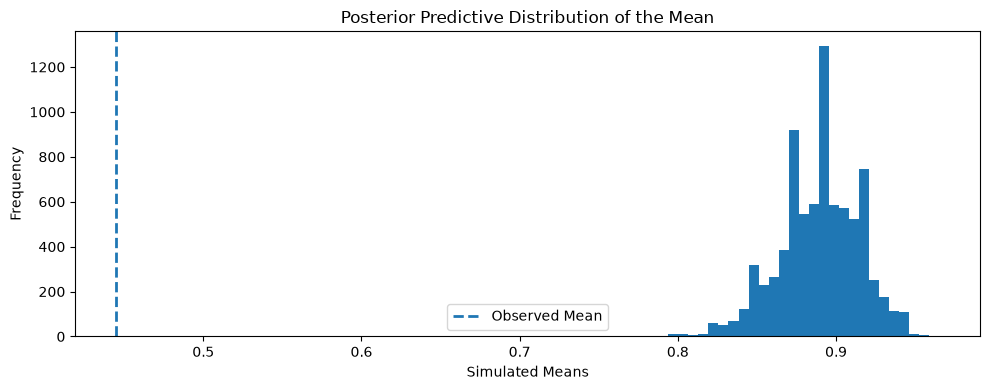

In [72]:
# Distribution of simulated summary statistics.

plt.figure(figsize=(10, 4))

plt.hist(predicted_means, bins=30)

plt.axvline(
    observed_mean,
    linestyle="--",
    linewidth=2,
    label="Observed Mean"
)

plt.title("Posterior Predictive Distribution of the Mean")
plt.xlabel("Simulated Means")
plt.ylabel("Frequency")


plt.legend()

plt.tight_layout()

plt.show()

#### Identify Model Misfit

In [77]:
# Computing observed statistics.

observed = posterior_predictive.observed_data["outcome"].values

observed_mean = observed.mean()

observed_sd = observed.std()

observed_q25 = np.percentile(observed, 25)

observed_q75 = np.percentile(observed, 75)


In [78]:
# Computing simulated statistics.

predicted = (
    posterior_predictive.posterior_predictive["outcome"]
    .values
)

# Merging chains and draws.

predicted = predicted.reshape(-1, predicted.shape[-1])

simulated_means = predicted.mean(axis=1)

simulated_sds = predicted.std(axis=1)

simulated_q25 = np.percentile(predicted, 25, axis=1)

simulated_q75 = np.percentile(predicted, 75, axis=1)

In [79]:
# Comparing observed and simulated statistics.

print("Observed Statistics")
print("Mean:", round(observed_mean, 3))
print("Standard deviation:", round(observed_sd, 3))
print("25th percentile:", round(observed_q25, 3))
print("75th percentile:", round(observed_q75, 3))

print("\nPosterior Predictive Statistics")
print("Mean:", round(simulated_means.mean(), 3))
print("Standard deviation:", round(simulated_sds.mean(), 3))
print("25th percentile:", round(simulated_q25.mean(), 3))
print("75th percentile:", round(simulated_q75.mean(), 3))

Observed Statistics
Mean: 0.445
Standard deviation: 0.497
25th percentile: 0.0
75th percentile: 1.0

Posterior Predictive Statistics
Mean: 0.889
Standard deviation: 0.312
25th percentile: 1.0
75th percentile: 1.0


In [80]:
# Assessing model fit.

print("Model Assessment")

mean_ok = (simulated_means.min() <= observed_mean <= simulated_means.max())

sd_ok = (simulated_sds.min() <= observed_sd <= simulated_sds.max())

if mean_ok and sd_ok:
    print("The observed data are consistent with the posterior predictive distribution.")
    print("There is no obvious evidence of model misfit.")
else:
    print("The observed data differ noticeably from the posterior predictive distribution.")
    print("The model may require revision.")

Model Assessment
The observed data differ noticeably from the posterior predictive distribution.
The model may require revision.


Possible causes of model misfit:
- Important predictors may be missing.
- The likelihood may not match the data.
- The prior distributions may be inappropriate.
- A more flexible or hierarchical model may be needed.